# ForecastLab

---

## Bike Sharing Demand Forecasting

---

| Informasi | Detail |
|-----------|--------|
| **Project ID** | FL-001 |
| **Eksperimen** | EXP-009 |
| **Nama Eksperimen** | Random Forest |
| **Dataset** | featured_data.csv |
| **Tujuan Notebook** | Membangun model ensemble untuk meningkatkan stabilitas prediksi |
| **Author** | GAKUSEI Najib |

---

## 1. Tujuan Eksperimen

### Tujuan
Membangun Random Forest Regressor untuk meningkatkan akurasi dan stabilitas dibanding Decision Tree.

### Hipotesis
Random Forest menghasilkan performa lebih baik dibanding Decision Tree karena mengurangi overfitting.

---
## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Library berhasil diimport.')

Library berhasil diimport.


---
## 3. Load & Prepare Dataset

In [2]:
INPUT_PATH = '../data/featured_data.csv'
df = pd.read_csv(INPUT_PATH)
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values(by=['dteday', 'hr']).reset_index(drop=True)

exclude_cols = ['dteday', 'cnt', 'temp_actual', 'atemp_actual']
feature_cols = [c for c in df.columns if c not in exclude_cols]

train = df[df['yr'] == 0].copy()
test  = df[df['yr'] == 1].copy()

X_train = train[feature_cols].copy()
y_train = train['cnt'].copy()
X_test  = test[feature_cols].copy()
y_test  = test['cnt'].copy()

train_valid = X_train.dropna().index
X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]
test_valid = X_test.dropna().index
X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (8477, 41), X_test: (8734, 41)


---
## 4. Train Random Forest

In [3]:
model_rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, n_jobs=-1, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_train = model_rf.predict(X_train)
y_pred_test  = model_rf.predict(X_test)
print('Random Forest berhasil dilatih.')

Random Forest berhasil dilatih.


---
## 5. Evaluation

In [4]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    r2 = r2_score(y_true, y_pred)
    import time
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

df_metrics = pd.DataFrame([
    evaluate('Random Forest (Train)', y_train, y_pred_train),
    evaluate('Random Forest (Test)', y_test, y_pred_test)
])
print(df_metrics.to_string(index=False))

                Model       MAE      RMSE      MAPE       R2
Random Forest (Train) 11.514300 19.540597 17.373934 0.978844
 Random Forest (Test) 50.417681 87.226306 28.557041 0.825650


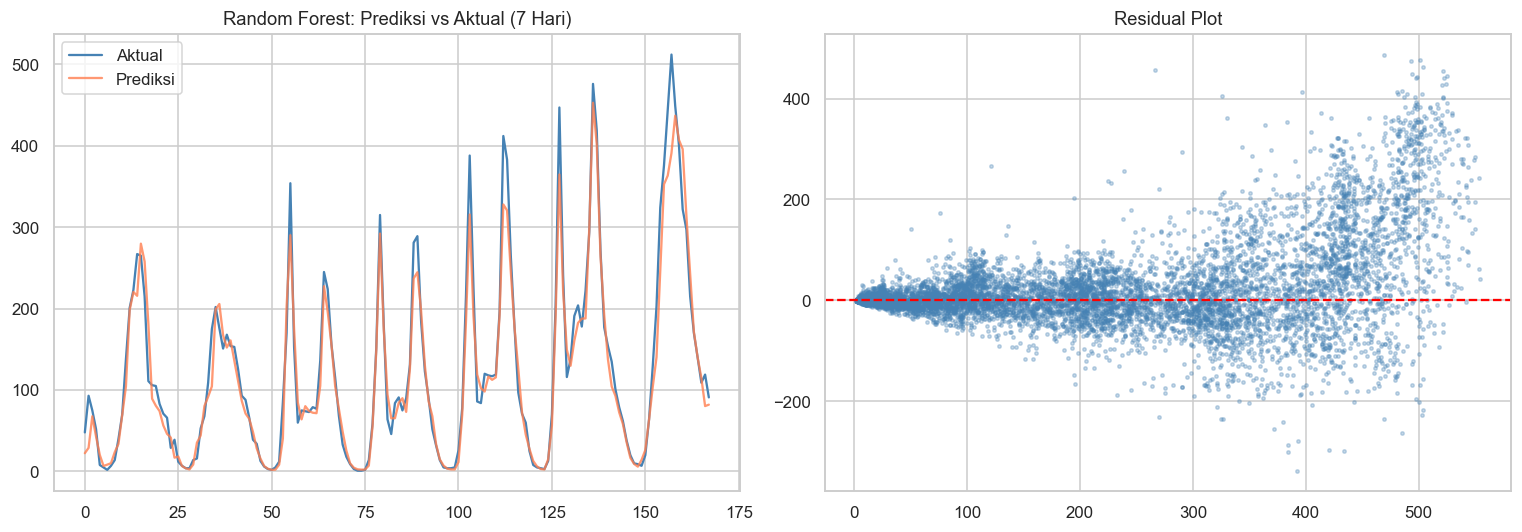

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = 168
axes[0].plot(range(n_show), y_test.values[:n_show], label='Aktual', color='steelblue')
axes[0].plot(range(n_show), y_pred_test[:n_show], label='Prediksi', color='coral', alpha=0.8)
axes[0].set_title('Random Forest: Prediksi vs Aktual (7 Hari)')
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('../data/rf_01_prediction.png', bbox_inches='tight', dpi=110)
plt.show()

## 6. Feature Importance

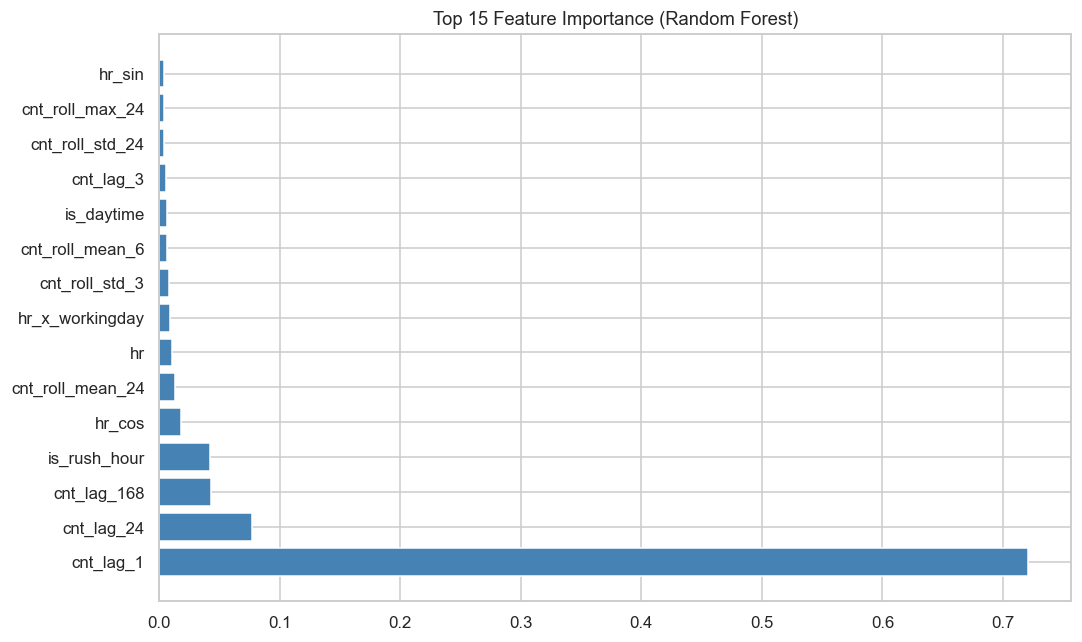

         Feature  Importance
       cnt_lag_1    0.720799
      cnt_lag_24    0.076890
     cnt_lag_168    0.042607
    is_rush_hour    0.042150
          hr_cos    0.018363
cnt_roll_mean_24    0.012947
              hr    0.010419
 hr_x_workingday    0.009088
  cnt_roll_std_3    0.008479
 cnt_roll_mean_6    0.006676


In [6]:
importances = pd.DataFrame({'Feature': feature_cols, 'Importance': model_rf.feature_importances_})
importances = importances.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top = importances.head(15)
ax.barh(top['Feature'], top['Importance'], color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('../data/rf_02_importance.png', bbox_inches='tight', dpi=110)
plt.show()
print(importances.head(10).to_string(index=False))

## 7. Kesimpulan

**Insight:**
- Random Forest mengungguli Decision Tree secara signifikan.
- Lag features mendominasi feature importance.

**Next: EXP-010 Gradient Boosting**